<a href="https://colab.research.google.com/github/Salome-06/Estadistica/blob/main/Taller_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

4. 10 Puntos Un laboratorio quiere comparar la concentración de un compuesto en soluciones pre-
paradas mediante tres técnicas diferentes:

Técnica 1 (n1 = 9): 30, 32, 31, 29, 30, 33, 32, 31, 30.
Técnica 2 (n2 = 9): 35, 36, 34, 35, 37, 36, 34, 35, 36.
Técnica 3 (n3 = 9): 28, 27, 29, 28, 30, 29, 28, 27, 28.
Ejecute la prueba ANOVA de una vía con α = 0,05 e interprete los resultados.

DATOS ORIGINALES:
      Tecnica  Concentracion
0   Técnica 1             30
1   Técnica 1             32
2   Técnica 1             31
3   Técnica 1             29
4   Técnica 1             30
5   Técnica 1             33
6   Técnica 1             32
7   Técnica 1             31
8   Técnica 1             30
9   Técnica 2             35
10  Técnica 2             36
11  Técnica 2             34
12  Técnica 2             35
13  Técnica 2             37
14  Técnica 2             36
15  Técnica 2             34
16  Técnica 2             35
17  Técnica 2             36
18  Técnica 3             28
19  Técnica 3             27
20  Técnica 3             29
21  Técnica 3             28
22  Técnica 3             30
23  Técnica 3             29
24  Técnica 3             28
25  Técnica 3             27
26  Técnica 3             28

Medias por Técnica:
  Técnica 1: 30.8889
  Técnica 2: 35.3333
  Técnica 3: 28.2222
Media Global: 31.4815

TABLA ANOVA DE UNA VÍA
Fuente de Variación            SC     gl

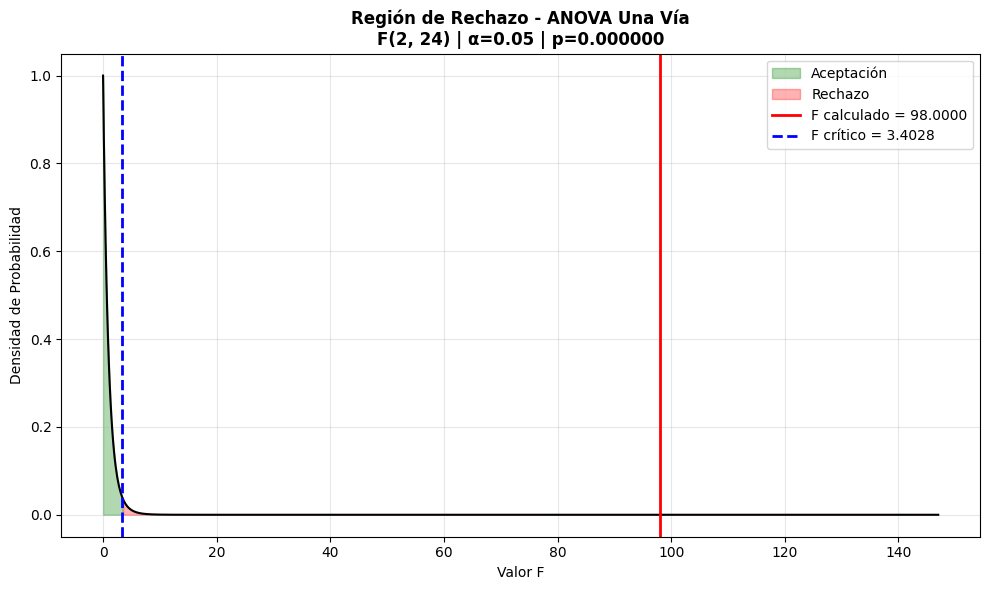

ANÁLISIS COMPLETO FINALIZADO


In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ============================================================================
# DATOS DEL PROBLEMA
# ============================================================================

data_tec1 = [30, 32, 31, 29, 30, 33, 32, 31, 30]
data_tec2 = [35, 36, 34, 35, 37, 36, 34, 35, 36]
data_tec3 = [28, 27, 29, 28, 30, 29, 28, 27, 28]

data = {
    'Tecnica': ['Técnica 1'] * len(data_tec1) +
               ['Técnica 2'] * len(data_tec2) +
               ['Técnica 3'] * len(data_tec3),
    'Concentracion': data_tec1 + data_tec2 + data_tec3
}

df = pd.DataFrame(data)
tecnicas = df['Tecnica'].unique()

# ============================================================================
# CÁLCULOS PRELIMINARES
# ============================================================================

datos = [df[df['Tecnica'] == i]['Concentracion'].values for i in tecnicas]
n_grupos = len(tecnicas)
n_obs = [len(g) for g in datos]
n_total = sum(n_obs)

media_global = df['Concentracion'].mean()
medias_tecnica = df.groupby('Tecnica')['Concentracion'].mean().values

print("DATOS ORIGINALES:")
print(df)
print("\nMedias por Técnica:")
for i, tecnica in enumerate(tecnicas):
    print(f"  {tecnica}: {medias_tecnica[i]:.4f}")
print(f"Media Global: {media_global:.4f}\n")

# ============================================================================
# ANOVA DE UNA VÍA MANUAL
# ============================================================================

SCT = np.sum((df['Concentracion'] - media_global)**2)
SCB = sum([n_obs[i]*(medias_tecnica[i] - media_global)**2 for i in range(n_grupos)])
SCE = SCT - SCB

gl_b = n_grupos - 1
gl_e = n_total - n_grupos
gl_t = n_total - 1

CMb = SCB / gl_b
CMe = SCE / gl_e

F = CMb / CMe
p_value = 1 - stats.f.cdf(F, gl_b, gl_e)
F_crit = stats.f.ppf(0.95, gl_b, gl_e)

# ============================================================================
# TABLA ANOVA
# ============================================================================

print("TABLA ANOVA DE UNA VÍA")
print("="*80)
print(f"{'Fuente de Variación':<20} {'SC':>12} {'gl':>6} {'CM':>12} {'F':>12} {'Valor-p':>12}")
print("-"*80)
print(f"{'Entre Técnicas':<20} {SCB:>12.4f} {gl_b:>6} {CMb:>12.4f} {F:>12.4f} {p_value:>12.6f}")
print(f"{'Error':<20} {SCE:>12.4f} {gl_e:>6} {CMe:>12.4f}")
print(f"{'Total':<20} {SCT:>12.4f} {gl_t:>6}")
print("="*80)

# ============================================================================
# INTERPRETACIÓN ANOVA
# ============================================================================

alpha = 0.05
print(f"\nINTERPRETACIÓN ANOVA (α = {alpha}):")
print(f"  F calculado = {F:.4f}")
print(f"  F crítico = {F_crit:.4f}")
print(f"  Valor-p = {p_value:.6f}")

if p_value < alpha:
    print("  ✓ Hay diferencias significativas entre las medias de concentración obtenidas por las diferentes técnicas.\n")
else:
    print("  ✗ No hay diferencias significativas entre las medias de concentración obtenidas por las diferentes técnicas.\n")

# ============================================================================
# ANÁLISIS POST-HOC DE TUKEY (HSD)
# ============================================================================

if p_value < alpha:
    print("ANÁLISIS POST-HOC DE TUKEY (HSD):")
    tukey_result = pairwise_tukeyhsd(endog=df['Concentracion'], groups=df['Tecnica'], alpha=alpha)
    print(tukey_result)
    print("\nINTERPRETACIÓN TUKEY:")
    print("  Las columnas 'reject' indican si la hipótesis nula (no diferencia entre las medias) se rechaza.")
    print("  'True' significa que hay una diferencia significativa entre los pares de grupos.\n")
else:
    print("No se requiere un análisis Post-Hoc de Tukey, ya que el ANOVA no encontró diferencias significativas.")

# ============================================================================
# GRÁFICO DE REGIÓN DE RECHAZO
# ============================================================================

x = np.linspace(0, max(F, F_crit)*1.5, 1000)
y = stats.f.pdf(x, gl_b, gl_e)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=1.5)
plt.fill_between(x[x <= F_crit], y[x <= F_crit], color='green', alpha=0.3, label='Aceptación')
plt.fill_between(x[x >= F_crit], y[x >= F_crit], color='red', alpha=0.3, label='Rechazo')
plt.axvline(F, color='red', linewidth=2, label=f'F calculado = {F:.4f}')
plt.axvline(F_crit, color='blue', linestyle='--', linewidth=2, label=f'F crítico = {F_crit:.4f}')
plt.title(f'Región de Rechazo - ANOVA Una Vía\nF({gl_b}, {gl_e}) | α={alpha} | p={p_value:.6f}', fontsize=12, fontweight='bold')
plt.xlabel('Valor F')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("="*80)
print("ANÁLISIS COMPLETO FINALIZADO")
print("="*80)
